In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/alammv/eda/refs/heads/main/adult.csv"
df = pd.read_csv(url, na_values="?")

df.shape
df.info()
df.describe()
df.isnull().sum()
df["income"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


,count
income,
<=50K,24720
>50K,7841


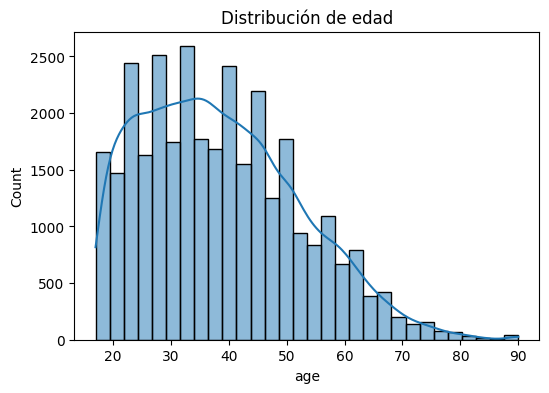

In [6]:
# GRAFICO 1

# 1. Distribución de edad
plt.figure(figsize=(6,4))
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Distribución de edad")
plt.show()


la mayoría de gente tiene entre 25 y 50 años, con un montón concentrado en los 35-40. Se nota la cola hacia la derecha, hay gente hasta los 90 pero son casos sueltos. Después de los 60 ya cae bastante la cantidad, tiene sentido porque a esa edad mucha gente ya se jubiló o trabaja menos. Prácticamente no hay nadie menor de 18, lo cual también es esperable en un dataset de ingresos laborales.

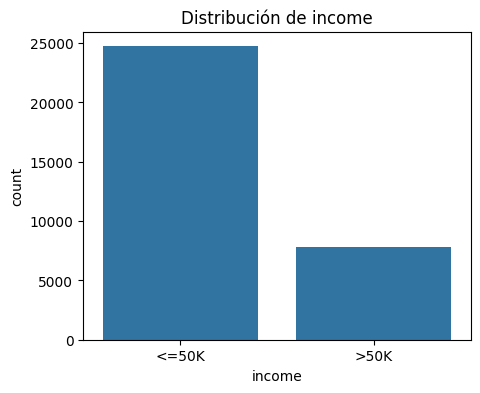

In [7]:
#GRAFICO 2

# 2. Balance del target
plt.figure(figsize=(5,4))
sns.countplot(x="income", data=df)
plt.title("Distribución de income")
plt.show()

hay bastante más gente ganando 50K o menos que gente ganando más, como 3 de cada 4 personas caen en ese grupo. O sea que el dataset está desbalanceado, no es mitad y mitad. Esto hay que tenerlo presente para cuando evaluemos el modelo, porque con un desbalance así el accuracy solo te puede engañar, un modelo que prediga siempre "<=50K" ya acertaría como 75% de las veces sin aprender nada.

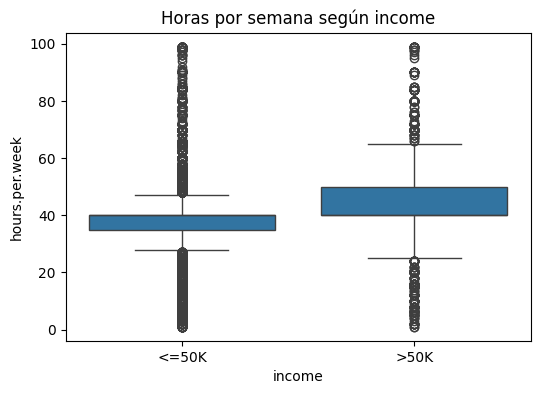

In [8]:
# GRAFICO 3

# 3. Horas trabajadas según income
plt.figure(figsize=(6,4))
sns.boxplot(x="income", y="hours.per.week", data=df)
plt.title("Horas por semana según income")
plt.show()

casi todo el mundo está pegado a las típicas 40 horas semanales, no importa si gana más o menos de 50K. Pero se nota una diferencia: el grupo que gana más de 50K tiende a estirarse un poco hacia arriba, hay bastantes casos entre 45 y 60 horas. El grupo que gana menos tiene más dispersión hacia abajo, con más gente en jornadas part-time o reducidas. Osea, trabajar más horas parece venir un poco de la mano con ganar más.

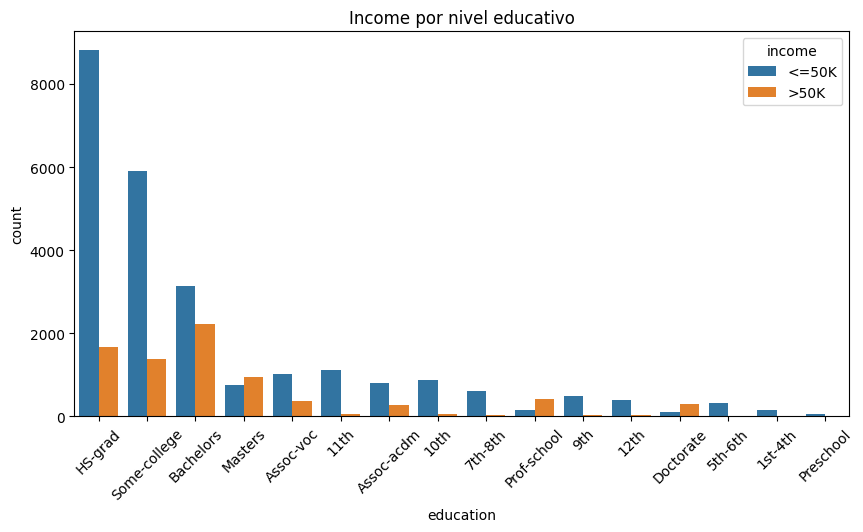

In [10]:
# GRAFICO 4

# 4. Income por nivel educativo
plt.figure(figsize=(10,5))
sns.countplot(x="education", hue="income", data=df, order=df["education"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Income por nivel educativo")
plt.show()

acá sí se nota una relación bien marcada. Entre más estudios tiene la persona, más chance de que esté en el grupo que gana más de 50K. Bachelors, Masters, Doctorate y Prof-school tienen una proporción grande cayendo en >50K, mientras que HS-grad para abajo (9th, 10th, 11th, etc) es casi todo <=50K. Esta probablemente termine siendo una de las variables más importantes para el modelo.

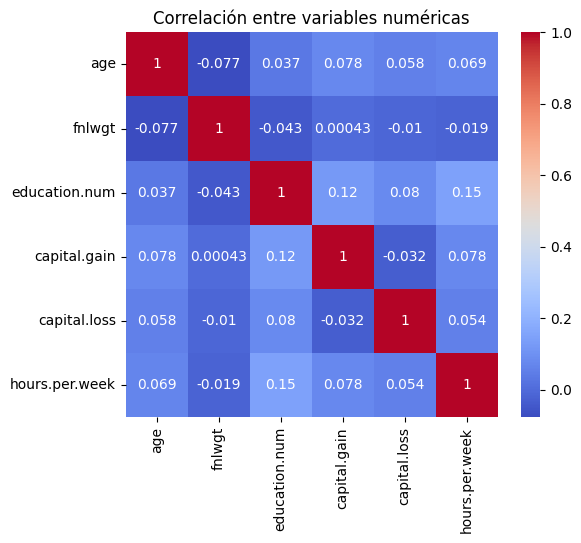

In [9]:
# GRAFICO 5

# 5. Correlación entre variables numéricas
plt.figure(figsize=(6,5))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlación entre variables numéricas")
plt.show()

en general las correlaciones entre las variables numéricas salen bajitas, ninguna pasa de 0.15 más o menos, así que no hay ninguna relación fuerte marcada. Lo único que se nota un poquito es education.num con hours.per.week y con capital.gain, osea que a más años de estudio hay algo más de horas trabajadas y de ganancias de capital, pero es una relación débil. fnlwgt no se correlaciona con nada del resto, lo cual tiene sentido porque es solo un peso estadístico que usa el censo para ponderar, no describe nada de la persona en sí.

In [11]:
print(df.isnull().sum())

df = df.dropna()
print(df.shape)

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64
(30162, 15)


isnull().sum() nos esta contando cuántos vacíos hay por columna, y dropna() borra esas filas. Como eran pocas comparadas con el total (30162 de 32561), no vale la pena rellenarlas ni complicarse asi que seria mejor sacarlas.

In [24]:
import pandas as pd

# Re-load data to ensure 'income' column is in its original string format.
url = "https://raw.githubusercontent.com/alammv/eda/refs/heads/main/adult.csv"
df = pd.read_csv(url, na_values="?")

# Apply dropna() to this dataframe, similar to cell N-_ah4Te0LcP
df = df.dropna()

# Debugging: Print unique values before mapping
print("Unique income values before mapping:")
print(df["income"].value_counts(dropna=False))
print(df["income"].str.strip().unique())

df["income"] = df["income"].str.strip().map({"<=50K": 0, ">50K": 1})

# Debugging: Print unique values after mapping
print("Unique income values AFTER mapping:")
print(df["income"].value_counts(dropna=False))

df_encoded = pd.get_dummies(df, columns=["workclass","education","marital.status","occupation","relationship","race","sex","native.country"], drop_first=True)

df_encoded.shape

Unique income values before mapping:
income
<=50K    22654
>50K      7508
Name: count, dtype: int64
['<=50K' '>50K']
Unique income values AFTER mapping:
income
0    22654
1     7508
Name: count, dtype: int64


(30162, 97)

El modelo solo entiende números, no texto. Por eso pasamos income a 0 y 1 a mano con map(), y el resto de categóricas las mandamos por get_dummies(), que crea una columna nueva por cada categoría con 0 o 1 según si aplica. El drop_first=True evita dejar una columna de más que ya se puede deducir de las otras.

In [25]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("income", axis=1)
y = df_encoded["income"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, X_test.shape

((24129, 96), (6033, 96))

Separamos lo que predice (X) de lo que queremos predecir (y), y partimos en 80% para entrenar y 20% para probar. stratify=y mantiene la proporción de 75/25 de income igual en ambos grupos.

In [26]:
from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

El RandomForestClassifier arma 100 árboles de decisión distintos y cada uno "vota", la predicción final es lo que dice la mayoría. fit() es donde el modelo aprende con los datos de entrenamiento.

Accuracy: 0.8549643626719708
Precision: 0.7466561762391818
Recall: 0.6318242343541944
F1: 0.6844572664983772


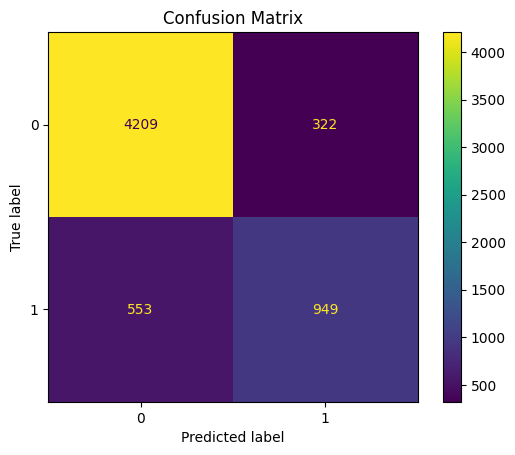

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

y_pred = modelo.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

predict() genera predicciones sobre el test (datos que el modelo nunca vio), y con eso sacamos las 4 métricas y la matriz de confusión, un resumen visual de en qué acertó y en qué se equivocó.

In [31]:
import joblib
from google.colab import files

joblib.dump(modelo, "modelo_random_forest.pkl", compress=3)
files.download("modelo_random_forest.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>